In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import plotly.express as px
from pathlib import Path
import geopandas as gpd
import folium
from folium.plugins import HeatMap

In [2]:
dir_path = Path(r"C:\Users\victo\OneDrive\Documents\Combined CSV Files")
air_quality_data = pd.concat((pd.read_csv(f, sep = ';', low_memory = False) for f in dir_path.glob('*.csv')), ignore_index=True)
air_quality_data

,sensor_id,sensor_type,location,lat,lon,timestamp,value_type,value
0,4962,pms5003,76,-1.261,36.782,2026-04-01T00:00:21+00:00,P2,8
1,4962,pms5003,76,-1.261,36.782,2026-04-01T00:00:21+00:00,P1,9
2,4962,pms5003,76,-1.261,36.782,2026-04-01T00:00:21+00:00,P0,5
3,4963,DHT22,76,-1.261,36.782,2026-04-01T00:00:23+00:00,humidity,97.2
4,4963,DHT22,76,-1.261,36.782,2026-04-01T00:00:23+00:00,temperature,18.4
...,...,...,...,...,...,...,...,...
3335635,4940,pms5003,3994,-0.297,36.088,2025-11-30T23:58:38+00:00,P2,40
3335636,4940,pms5003,3994,-0.297,36.088,2025-11-30T23:58:38+00:00,P1,45
3335637,4940,pms5003,3994,-0.297,36.088,2025-11-30T23:58:38+00:00,P0,24
3335638,4941,DHT22,3994,-0.297,36.088,2025-11-30T23:58:40+00:00,humidity,62.9


In [3]:
air_quality_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3335640 entries, 0 to 3335639
Data columns (total 8 columns):
 #   Column       Dtype  
---  ------       -----  
 0   sensor_id    int64  
 1   sensor_type  str    
 2   location     int64  
 3   lat          object 
 4   lon          float64
 5   timestamp    str    
 6   value_type   str    
 7   value        str    
dtypes: float64(1), int64(2), object(1), str(4)
memory usage: 203.6+ MB


In [3]:
air_quality_data['value'] = pd.to_numeric(air_quality_data['value'], errors='coerce')

In [17]:
air_quality_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 661784 entries, 2025-11-01 00:00:15+00:00 to 2026-04-06 04:55:25+00:00
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   sensor_id    661784 non-null  int64  
 1   sensor_type  661784 non-null  str    
 2   location     661784 non-null  int64  
 3   lat          661784 non-null  str    
 4   lon          661784 non-null  float64
 5   value_type   661784 non-null  str    
 6   value        661681 non-null  float64
dtypes: float64(2), int64(2), str(3)
memory usage: 40.4 MB


In [4]:
air_quality_data.timestamp = pd.to_datetime(air_quality_data.timestamp, format="ISO8601")
air_quality_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3335640 entries, 0 to 3335639
Data columns (total 8 columns):
 #   Column       Dtype              
---  ------       -----              
 0   sensor_id    int64              
 1   sensor_type  str                
 2   location     int64              
 3   lat          object             
 4   lon          float64            
 5   timestamp    datetime64[us, UTC]
 6   value_type   str                
 7   value        float64            
dtypes: datetime64[us, UTC](1), float64(2), int64(2), object(1), str(2)
memory usage: 203.6+ MB


In [5]:
air_quality_data.set_index('timestamp', inplace = True)

In [13]:
air_quality_data.head()

,sensor_id,sensor_type,location,lat,lon,value_type,value
timestamp,,,,,,,
2026-04-01 00:00:21+00:00,4962,pms5003,76,-1.261,36.782,P1,9
2026-04-01 00:00:21+00:00,4962,pms5003,76,-1.261,36.782,P0,5
2026-04-01 00:00:23+00:00,4963,DHT22,76,-1.261,36.782,humidity,97.2
2026-04-01 00:00:23+00:00,4963,DHT22,76,-1.261,36.782,temperature,18.4
2026-04-01 00:00:53.467669+00:00,4930,pms5003,3981,-1.269,36.819,P2,20.2


In [6]:
air_quality_data = air_quality_data.sort_index()

In [7]:
grouped_aq_values = air_quality_data.groupby('value_type').resample('D')[['value']].mean().groupby(level=0).rolling(window=3).mean()
grouped_aq_values.head(20)


value
value_type value_type timestamp                            
P0         P0         2025-11-01 00:00:00+00:00         NaN
                      2025-11-02 00:00:00+00:00         NaN
                      2025-11-03 00:00:00+00:00  175.213505
                      2025-11-04 00:00:00+00:00   83.234962
                      2025-11-05 00:00:00+00:00   29.142930
                      2025-11-06 00:00:00+00:00   25.752317
                      2025-11-07 00:00:00+00:00   24.049107
                      2025-11-08 00:00:00+00:00   22.059248
                      2025-11-09 00:00:00+00:00   21.217884
                      2025-11-10 00:00:00+00:00   23.097005
                      2025-11-11 00:00:00+00:00   24.188322
                      2025-11-12 00:00:00+00:00   25.451028
                      2025-11-13 00:00:00+00:00   22.076761
                      2025-11-14 00:00:00+00:00   25.745902
                      2025-11-15 00:00:00+00:00   25.297302
                      2025-11-16 00:00:00+00:00   25.448717
                      2025-11-17 00:00:00+00:00   22.471105
                      2025-11-18 00:00:00+00:00   22.688024
                      2025-11-19 00:00:00+00:00   25.380727
                      2025-11-20 00:00:00+00:00   27.234863

In [8]:
grouped_aq_values.isnull().sum()

value    18
dtype: int64

In [8]:
grouped_aq_values.dropna(inplace = True)

In [59]:
print(grouped_aq_values.columns)

Index(['value'], dtype='str')


In [60]:
grouped_aq_values.index

MultiIndex([(         'P0',          'P0', '2025-11-03 00:00:00+00:00'),
            (         'P0',          'P0', '2025-11-04 00:00:00+00:00'),
            (         'P0',          'P0', '2025-11-05 00:00:00+00:00'),
            (         'P0',          'P0', '2025-11-06 00:00:00+00:00'),
            (         'P0',          'P0', '2025-11-07 00:00:00+00:00'),
            (         'P0',          'P0', '2025-11-08 00:00:00+00:00'),
            (         'P0',          'P0', '2025-11-09 00:00:00+00:00'),
            (         'P0',          'P0', '2025-11-10 00:00:00+00:00'),
            (         'P0',          'P0', '2025-11-11 00:00:00+00:00'),
            (         'P0',          'P0', '2025-11-12 00:00:00+00:00'),
            ...
            ('temperature', 'temperature', '2026-03-28 00:00:00+00:00'),
            ('temperature', 'temperature', '2026-03-29 00:00:00+00:00'),
            ('temperature', 'temperature', '2026-03-30 00:00:00+00:00'),
            ('temperature', 'temper

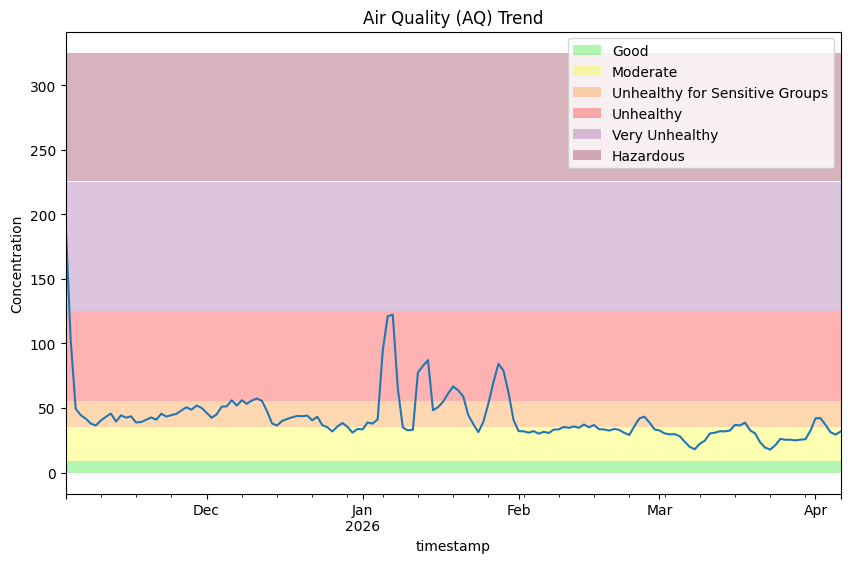

In [10]:
Pollutant = input('Choose Option: (1). P1\n(2). P2')
p_df = grouped_aq_values.xs(Pollutant, level=1)
p_df = p_df.reset_index(level=0, drop=True)

aqi_levels = [
    ("Good", 0, 9, "#00e400"),
    ("Moderate", 9.1, 35.4, "#ffff00"),
    ("Unhealthy for Sensitive Groups", 35.5, 55.4, "#ff7e00"),
    ("Unhealthy", 55.5, 125.4, "#ff0000"),
    ("Very Unhealthy", 125.5, 225.4, "#8f3f97"),
    ("Hazardous", 225.5, 325.4, "#7e0023")
]


fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Air Quality (AQ) Trend')
ax.set_ylabel('Concentration')
for label, lo, hi, color in aqi_levels:
    ax.axhspan(lo, hi, facecolor=color, alpha=0.3, label=label)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
p_df['value'].plot(ax = ax)
plt.show()

In [9]:
air_quality_data['lat'] = pd.to_numeric(air_quality_data['lat'], errors='coerce')

In [10]:
air_quality_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3335640 entries, 2025-11-01 00:00:15+00:00 to 2026-04-06 04:56:18+00:00
Data columns (total 7 columns):
 #   Column       Dtype  
---  ------       -----  
 0   sensor_id    int64  
 1   sensor_type  str    
 2   location     int64  
 3   lat          float64
 4   lon          float64
 5   value_type   str    
 6   value        float64
dtypes: float64(3), int64(2), str(2)
memory usage: 203.6 MB


In [13]:
air_quality_data.isnull().sum()

sensor_id        0
sensor_type      0
location         0
lat            845
lon              0
value_type       0
value          249
dtype: int64

In [10]:
air_quality_data.dropna(inplace=True)

In [11]:
m = folium.Map(location=[-1.2921, 36.8219], zoom_start=4)

heat_data = [[row['lat'], row['lon'], row['value']] for index, row in air_quality_data.iterrows()]

HeatMap(heat_data).add_to(m)

m.save("air_quality_map.html")

In [37]:
aq_data_nakuru = pd.read_csv(r"C:\Users\victo\OneDrive\Documents\CSV files Nakuru\combined_6_months_nakuru.csv", sep = ';', low_memory = False)
aq_data_nakuru.columns = ['sensor_id','sensor_type','location','lat','lon','timestamp','value_type','value']
aq_data_nakuru.head()

,sensor_id,sensor_type,location,lat,lon,timestamp,value_type,value
0,4940,pms5003,3994,-0.297,36.088,2026-04-01T00:00:09+00:00,P1,35
1,4940,pms5003,3994,-0.297,36.088,2026-04-01T00:00:09+00:00,P0,23
2,4941,DHT22,3994,-0.297,36.088,2026-04-01T00:00:11+00:00,humidity,79.8
3,4941,DHT22,3994,-0.297,36.088,2026-04-01T00:00:11+00:00,temperature,17.8
4,4922,pms5003,3977,0.371,35.943,2026-04-01T00:00:15.524676+00:00,P2,10
